In [1]:
# Importando os pacotes | Importing the packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Criando o Data Frame
df = pd.read_csv("survey_data.csv")
pd.set_option('display.max_columns', None)

In [3]:
# Vendo as primeiras 5 linhas do Data Frame
df.head(5)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

In [4]:
df.shape

(65457, 114)

In [5]:
# Filtrando e entendendo as colunas com valores duplicados
df.apply(lambda col: col.duplicated().sum())

ResponseId                20
MainBranch             65452
Age                    65449
Employment             65347
RemoteWork             65453
                       ...  
JobSatPoints_11        65377
SurveyLength           65453
SurveyEase             65453
ConvertedCompYearly    59343
JobSat                 65445
Length: 114, dtype: int64

In [9]:
# Após perceber que a coluna ResponseId não pode possuir valores duplicados, iremos remover todos dessa coluna
df.drop_duplicates(subset=['ResponseId'], inplace=True)

In [31]:
# Tratando valores ausentes
df['EdLevel'] = df['EdLevel'].fillna('Bachelor’s degree (B.A., B.S., B.Eng., etc.)')
df['Employment'] = df['Employment'].fillna('Employed, full-time')
df['EdLevel'] = df['EdLevel'].str.replace(r" \(.+\)", "", regex=True) # Apagando alguns textos da coluna para facilitar a visualização nos gráficos
df['RemoteWork'] = df['RemoteWork'].fillna('Hybrid (some remote, some in-person)')
df = df.dropna(subset=['ConvertedCompYearly']) 

In [66]:
# Trantando a coluna Employment para remover inconsistências
# Removendo os aposentados e quem está registrado como trabalha e não trabalha ao mesmo tempo
trabalha = df['Employment'].str.contains('Employed', na=False)
nao_trabalha = df['Employment'].str.contains('Not employed', na=False)

inconsistentes = df[trabalha & nao_trabalha]

df = df[~(trabalha & nao_trabalha)] # Remove inconsistência de quem trabalha / não trabalha ao mesmo tempo
df = df[df['Employment'] != 'Retired'] # Remove quem é aposentado

In [40]:
# Removendo valores quebrados na coluna Anos de experiência para facilitar a análise
df["YearsCodePro"] = df["YearsCodePro"].replace(
    "Less than 1 year",
    1
)

df["YearsCodePro"] = df["YearsCodePro"].replace(
    "More than 50 years",
    50
)

# Alterando a coluna de idade para valores numéricos
map_idades = {
    'Under 18 years old': 15,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    '18-24 years old': 23
}

df['Age'] = df['Age'].replace(map_idades)
df = df[df['Age'] != 'Prefer not to say']

C:\Users\Andre\AppData\Local\Temp\ipykernel_1336\3329529551.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Age'] = df['Age'].replace(map_idades)


In [12]:
# Utilizando o método IQR para remover valores discrepantes da coluna ConvertedCompYearly (Remuneração anual)
# Calculando o IQR
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# 2. Definir os limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Alterando o dataframe
df = df[(df['ConvertedCompYearly'] >= limite_inferior) & 
              (df['ConvertedCompYearly'] <= limite_superior)]

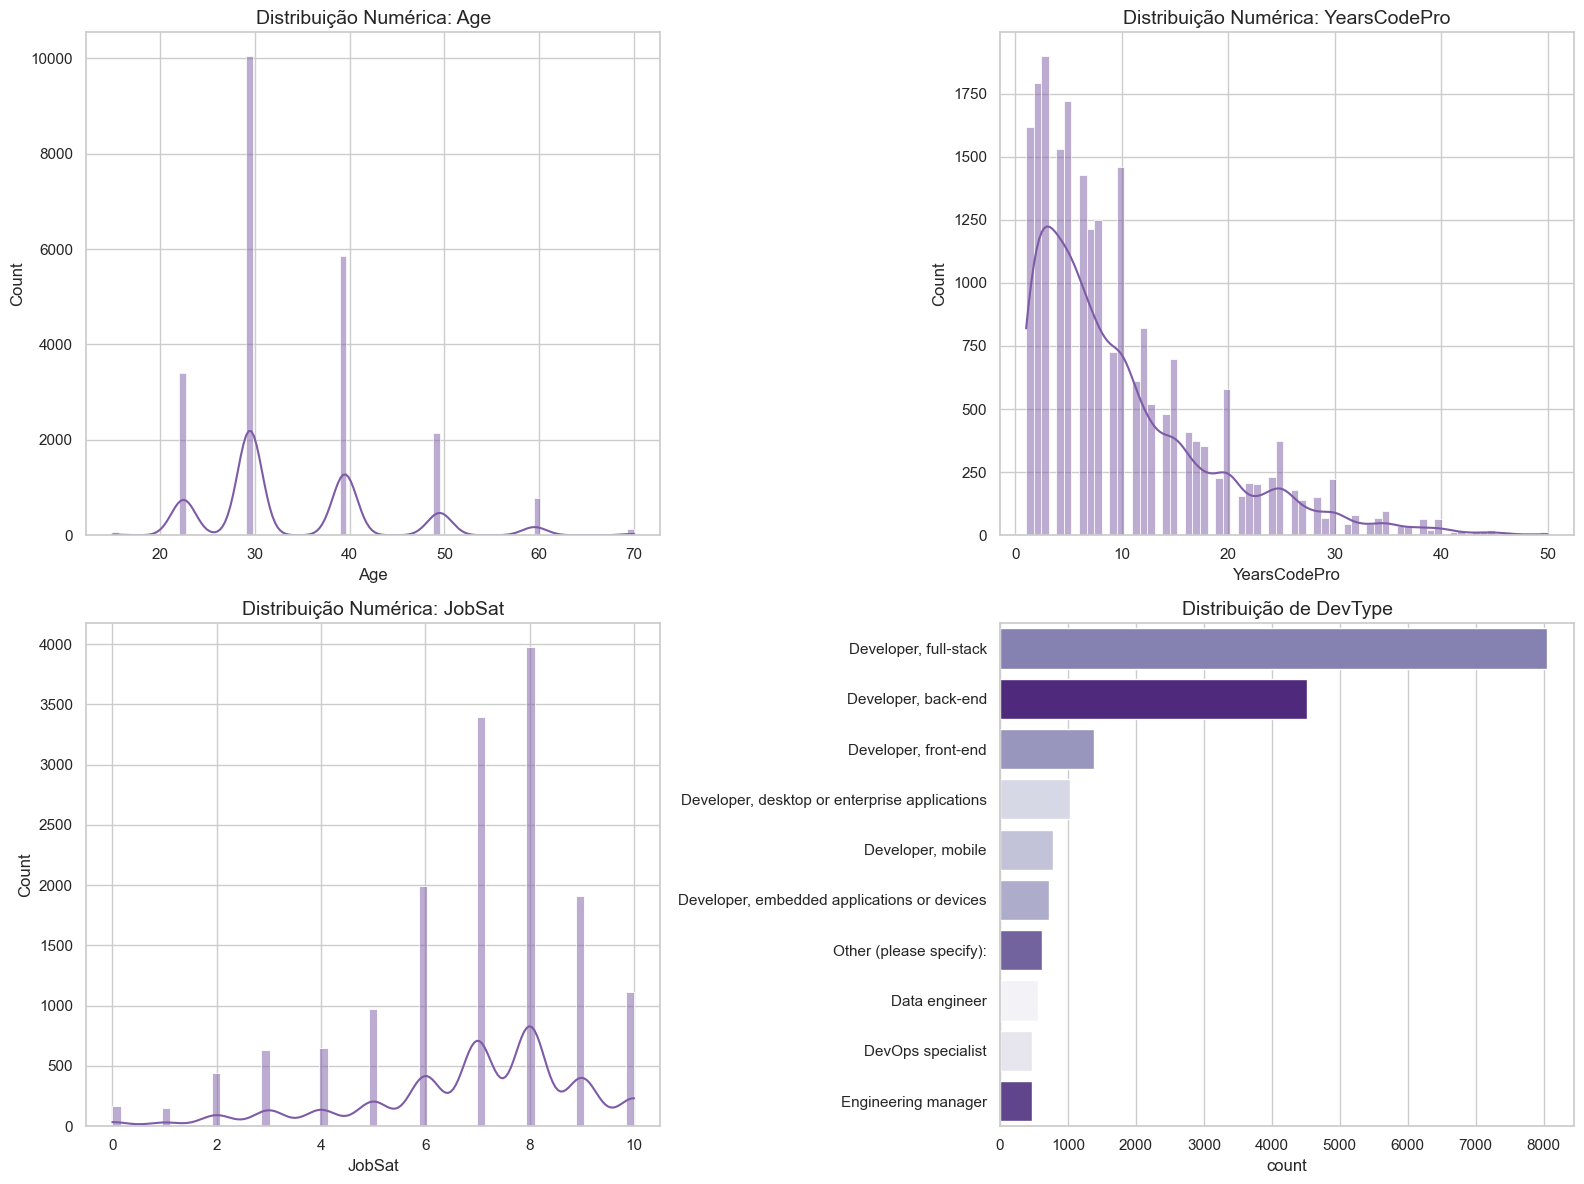

In [68]:
# Analisando a distribuição de Idade, Anos de experiência, Satisfação no trabalho e Modelo de trabalho

colunas = ['Age', 'YearsCodePro', 'JobSat', 'DevType']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()
cor_roxa = "#7d5ba6" 

for i, col in enumerate(colunas):
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(data=df, x=col, ax=axes_flat[i], kde=True, color=cor_roxa)
        axes_flat[i].set_title(f'Distribuição Numérica: {col}', fontsize=14)
    
    else:
        contagem = df[col].value_counts()
        top_values = contagem.nlargest(10).index
        
        df_top = df[df[col].isin(top_values)]
        
        sns.countplot(
            data=df_top, 
            y=col, 
            ax=axes_flat[i], 
            hue=col, 
            palette='Purples_r', 
            order=top_values,
            legend=False
        )
        
        axes_flat[i].set_title(f'Distribuição de {col}', fontsize=14)
        axes_flat[i].set_ylabel('')

plt.tight_layout()
plt.show()

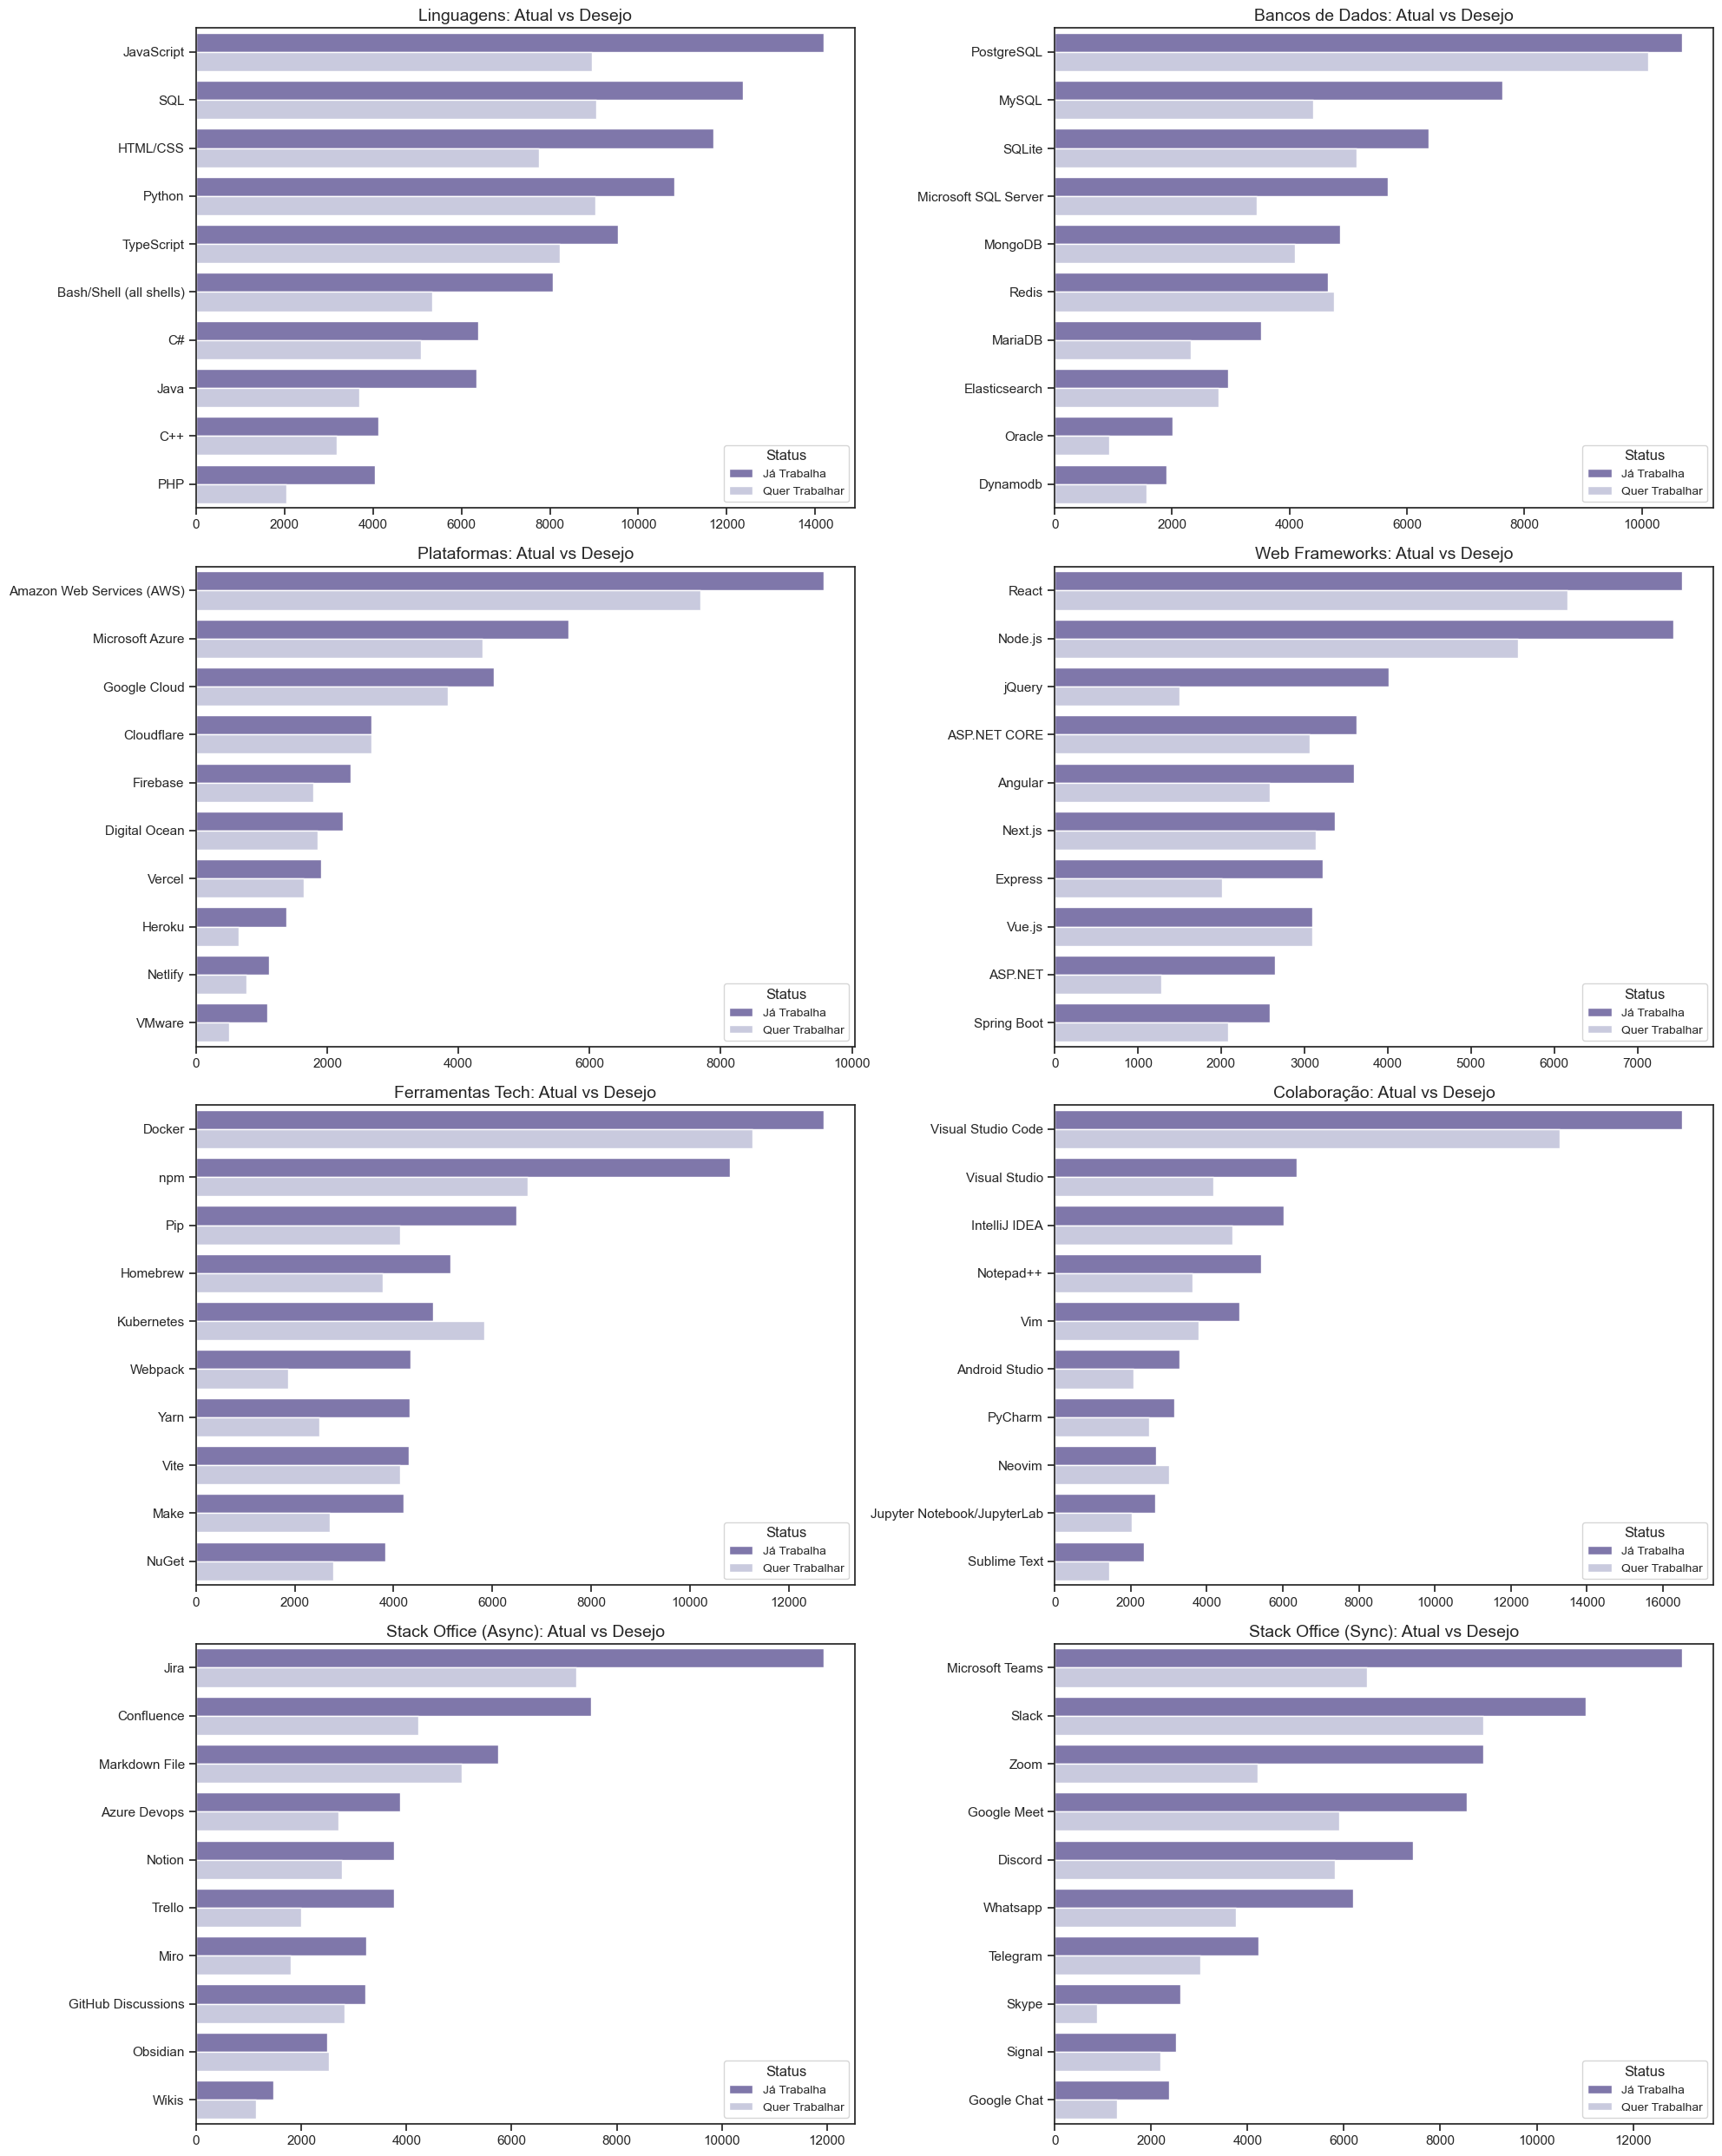

In [22]:
# Entendendo as principais tecnologias que são utilizadas e quais os entrevistados querem utilizar

def preparar_dados(df, col_have, col_want, top=10):
    have = df[col_have].str.get_dummies(sep=';').sum().sort_values(ascending=False).head(top)
    want = df[col_want].str.get_dummies(sep=';').sum().reindex(have.index).fillna(0)
    df_plot = pd.DataFrame({
        'Tecnologia': have.index,
        'Já Trabalha': have.values,
        'Quer Trabalhar': want.values
    }).melt(id_vars='Tecnologia', var_name='Status', value_name='Total')
    return df_plot
    
categorias = [
    ('LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'Linguagens'),
    ('DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'Bancos de Dados'),
    ('PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'Plataformas'),
    ('WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'Web Frameworks'),
    ('ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'Ferramentas Tech'),
    ('NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'Colaboração'),
    ('OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'Stack Office (Async)'),
    ('OfficeStackSyncHaveWorkedWith', 'OfficeStackSyncWantToWorkWith', 'Stack Office (Sync)')
]

fig, axes = plt.subplots(4, 2, figsize=(20, 25))
axes_flat = axes.flatten()

for i, (col_have, col_want, titulo) in enumerate(categorias):
    df_res = preparar_dados(df, col_have, col_want)
    
    sns.barplot(
        data=df_res, 
        x='Total', 
        y='Tecnologia', 
        hue='Status', 
        ax=axes_flat[i],
        palette='Purples_r'
    )
    
    axes_flat[i].set_title(f'{titulo}: Atual vs Desejo', fontsize=14)
    axes_flat[i].set_ylabel('')
    axes_flat[i].set_xlabel('')
    axes_flat[i].legend(title='Status', fontsize=10)

plt.tight_layout()
plt.show()

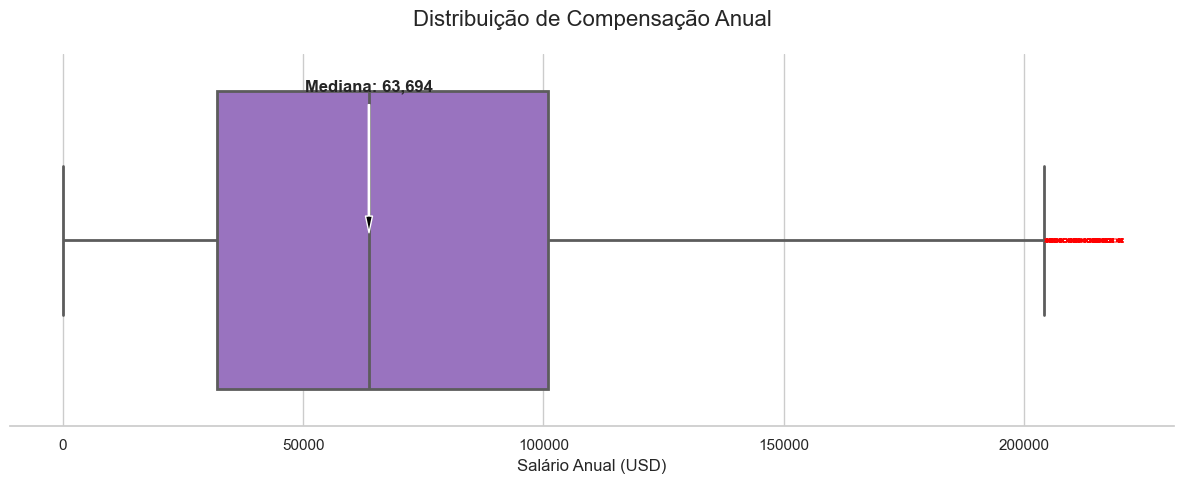

In [50]:
# Analisando a distribuição de remuneração total dos entrevistados
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

ax = sns.boxplot(
    x=df['ConvertedCompYearly'], 
    color="#9966CC",      
    linewidth=2,          
    fliersize=3,          
    flierprops={"marker": "x", "markeredgecolor": "red"} 
)

mediana = df['ConvertedCompYearly'].median()
ax.annotate(f'Mediana: {mediana:,.0f}', 
            xy=(mediana, 0), xytext=(mediana, -0.4),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
            fontsize=12, fontweight='bold', ha='center')

plt.title('Distribuição de Compensação Anual', fontsize=16, pad=20)
plt.xlabel('Salário Anual (USD)', fontsize=12)
plt.xticks(fontsize=11)

sns.despine(left=True)

plt.tight_layout()
plt.show()

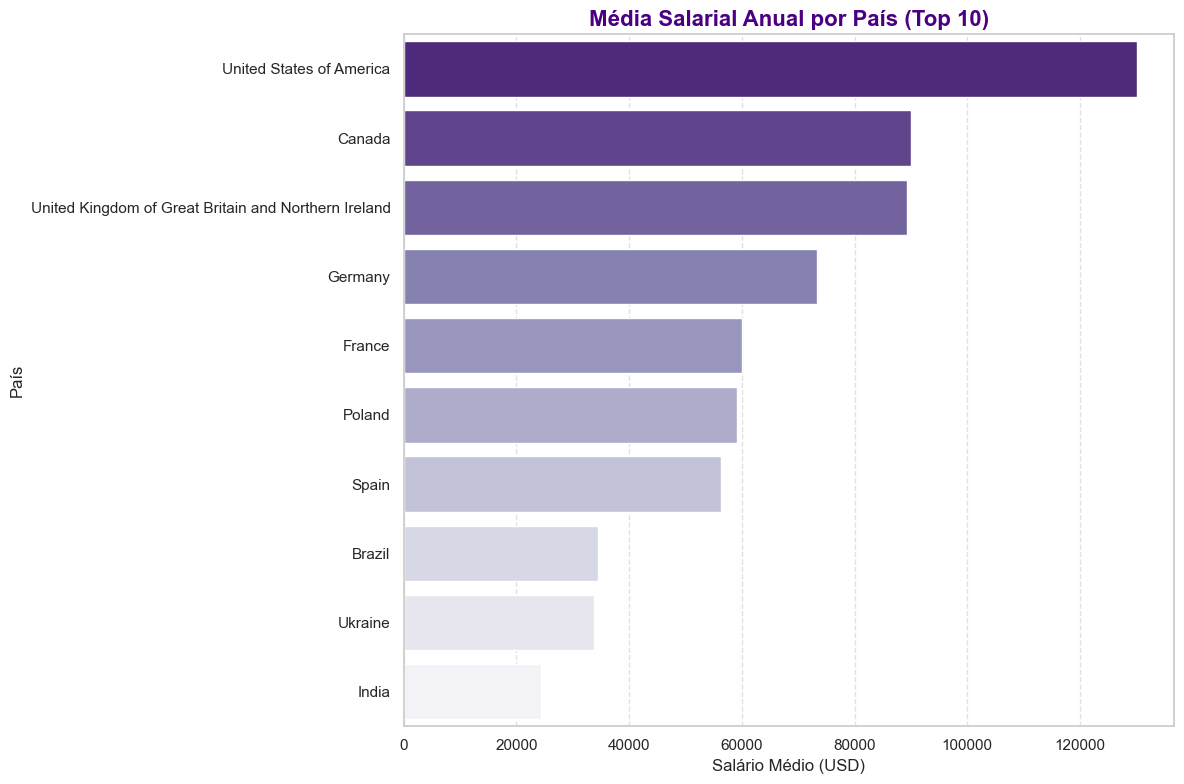

In [47]:
# 1. Calculando a média salarial por país e ordenando
media_salarial_paises = df_top10.groupby('Country')['ConvertedCompYearly'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=media_salarial_paises.values, 
    y=media_salarial_paises.index, 
    hue=media_salarial_paises.index,
    palette='Purples_r',
    legend=False
)

plt.title('Média Salarial Anual por País (Top 10)', fontsize=16, fontweight='bold', color='#4B0082')
plt.xlabel('Salário Médio (USD)', fontsize=12)
plt.ylabel('País', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

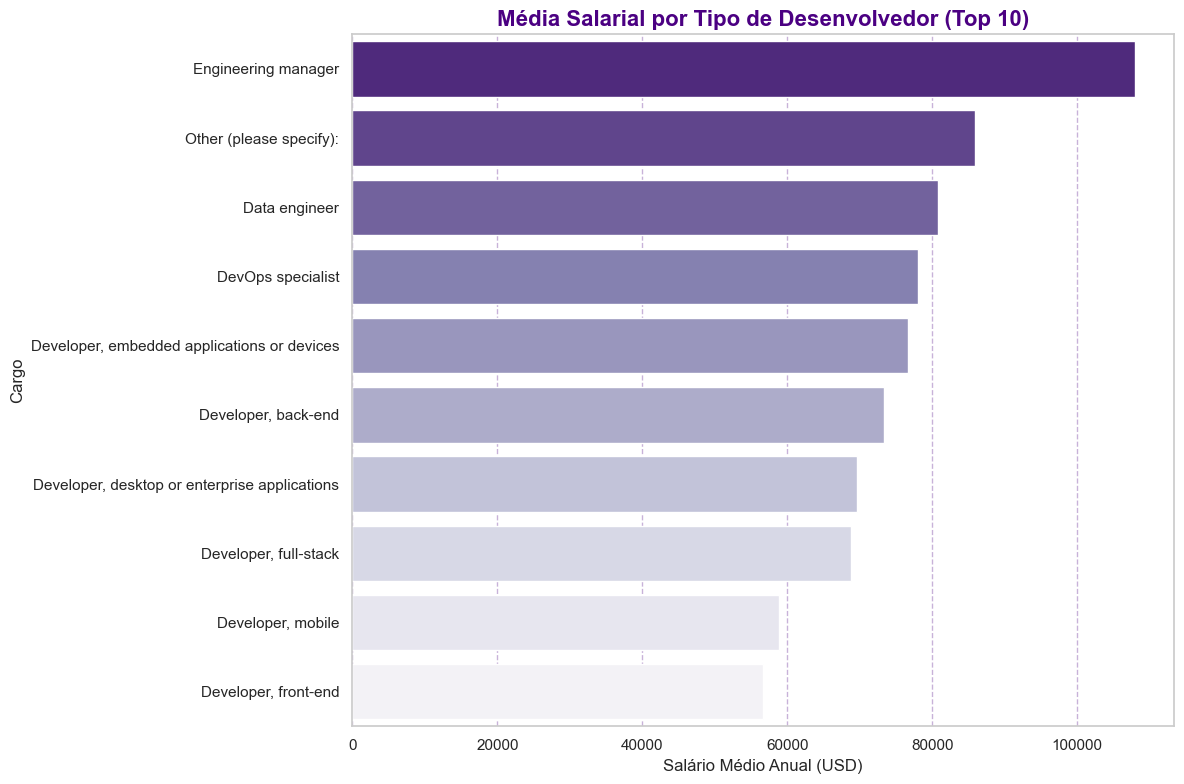

In [69]:
# Analisando os cargos que possuem a maior média salarial
top_10_devtypes = df['DevType'].value_counts().nlargest(10).index
df_dev_top = df[df['DevType'].isin(top_10_devtypes)]

media_dev = df_dev_top.groupby('DevType')['ConvertedCompYearly'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=media_dev.values, 
    y=media_dev.index, 
    hue=media_dev.index,
    palette='Purples_r',
    legend=False
)

plt.title('Média Salarial por Tipo de Desenvolvedor (Top 10)', fontsize=16, fontweight='bold', color='#4B0082')
plt.xlabel('Salário Médio Anual (USD)', fontsize=12)
plt.ylabel('Cargo', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3, color='#4B0082')

plt.tight_layout()
plt.show()

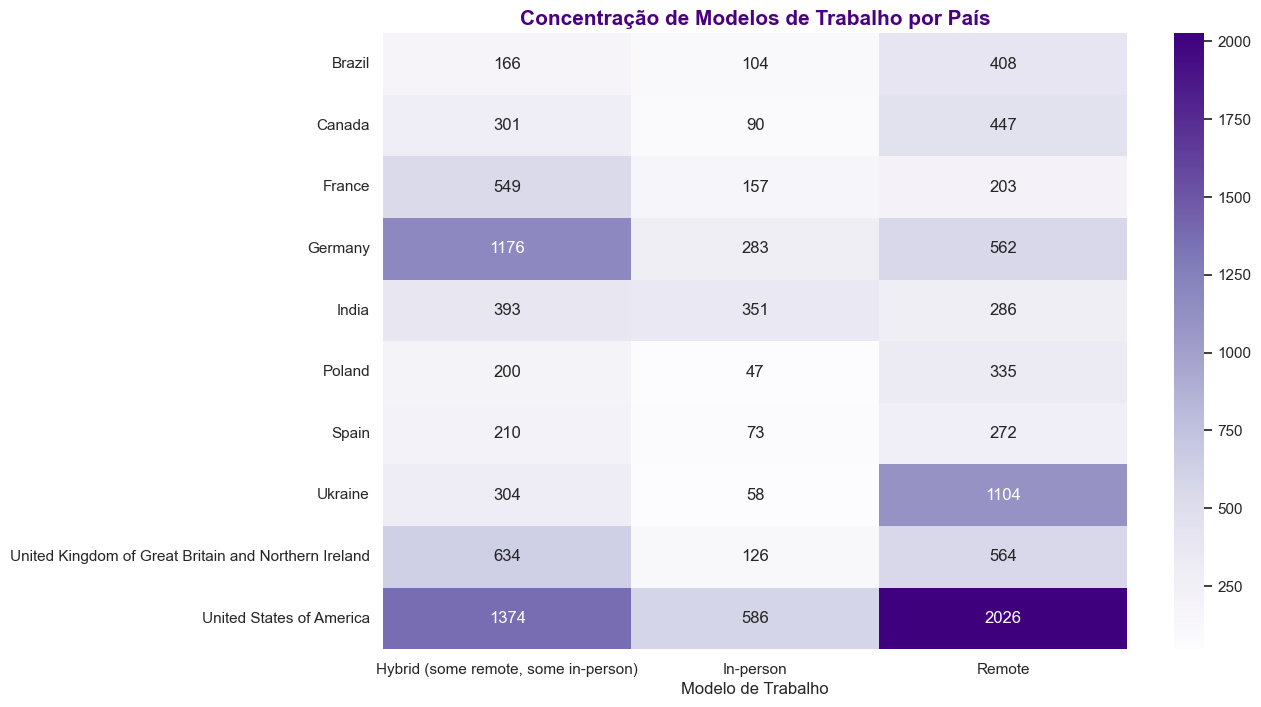

In [46]:
# Entendo os modelos de trabalho pelos 10 maiores países
top_10_paises = df['Country'].value_counts().head(10).index
df_filtrado = df[df['Country'].isin(top_10_paises)]

tabela_calor = pd.crosstab(df_filtrado['Country'], df_filtrado['RemoteWork'])

plt.figure(figsize=(12, 8))

sns.heatmap(
    tabela_calor, 
    annot=True, 
    fmt="d", 
    cmap="Purples", 
    cbar=True,
    annot_kws={"size": 12}
)

plt.title('Concentração de Modelos de Trabalho por País', fontsize=15, fontweight='bold', color='#4B0082')
plt.xlabel('Modelo de Trabalho', fontsize=12)
plt.ylabel('', fontsize=12)

plt.show()

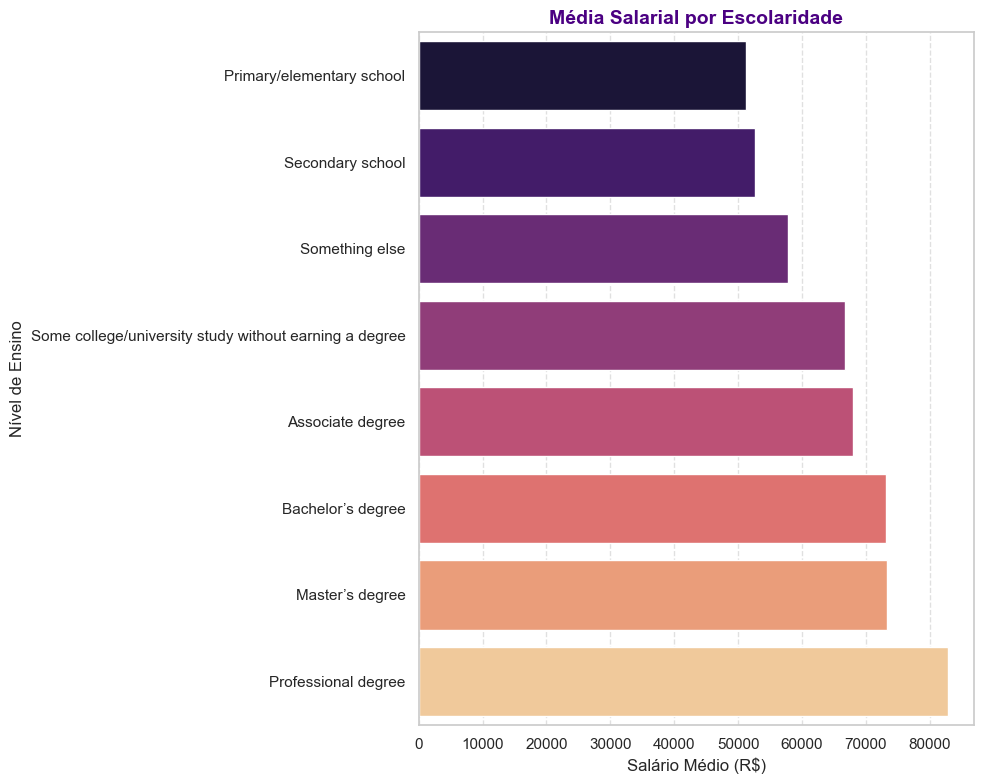

In [33]:
# Calculando a média de remuneração anual por Escolaridade
media_por_escolaridade = df.groupby('EdLevel')['ConvertedCompYearly'].mean().sort_values()

plt.figure(figsize=(10, 8)) # Aumentamos a altura (8) para caber as linhas

sns.barplot(
    y=media_por_escolaridade.index,   # A escolaridade agora vai para o Y
    x=media_por_escolaridade.values,  # O valor do salário agora vai para o X
    hue=media_por_escolaridade.index, 
    palette='magma',
    legend=False
)

plt.title('Média Salarial por Escolaridade', fontsize=14, fontweight='bold', color='#4B0082')
plt.xlabel('Salário Médio (R$)', fontsize=12)
plt.ylabel('Nível de Ensino', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

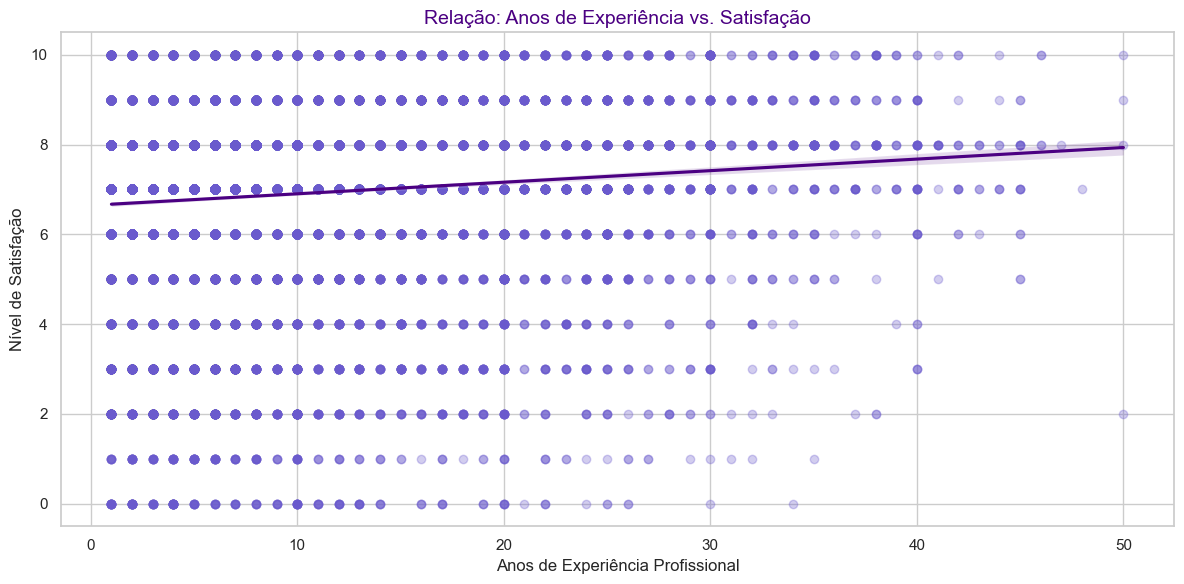

In [36]:
# Analisando a relação de tempo de experiência e satisfação no trabalho
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

plt.figure(figsize=(12, 6))

sns.regplot(
    data=df, 
    x='YearsCodePro', 
    y='JobSat',
    scatter_kws={'alpha':0.3, 'color': '#6A5ACD'},
    line_kws={'color': '#4B0082'}
)

plt.title('Relação: Anos de Experiência vs. Satisfação', fontsize=14, color='#4B0082')
plt.xlabel('Anos de Experiência Profissional', fontsize=12)
plt.ylabel('Nível de Satisfação', fontsize=12)

plt.tight_layout()
plt.show()